**RDGY41710** Practical Session: eXplainable AI, Gradient-weighted Class Activation Mapping (GradCAM)

June, 2024

In [ ]:
# import statements

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch.optim import lr_scheduler

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Exploring the CIFAR10 Dataset

For this tutorial, we'll use the CIFAR10 dataset, which consists of 60000 32x32 px colour images in 10 classes. Here are some sample images from the dataset:

<img src="https://miro.medium.com/max/709/1*LyV7_xga4jUHdx4_jHk1PQ.png" style="max-width:480px">

In [ ]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
# prepare data transformation
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

In [ ]:
# CIFAR-10 dataset loading and normalization

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

100%|██████████| 170498071/170498071 [00:03<00:00, 47342548.14it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


Build a simple CNN model.

In [ ]:
class CIFAR10Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 64 x 16 x 16

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 128 x 8 x 8

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 256 x 4 x 4

            nn.Flatten(),
            nn.Linear(256*4*4, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 10))

    def forward(self, x):
        return self.network(x)

model = CIFAR10Model().to(device)

In [ ]:
lr = 0.0005
# optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
optimizer = torch.optim.Adam(model.parameters(), lr= lr)
loss_fn = torch.nn.CrossEntropyLoss()

Train model.

In [ ]:
train_loss = []
train_acc = []
total_tr_step = len(trainloader)
num_epochs = 15  # number of epochs

for epoch in range(1, num_epochs+1):
    i = 0
    error_count = 0.0
    running_loss = 0.0
    train_correct = 0
    train_total=0

    #with tqdm(train_loader, unit="batch") as tepoch:

    for image, target in iter(tqdm(trainloader)):
      image = image.to(device)
      target = target.to(device)
      # clear the gradients of all optimized variables
      optimizer.zero_grad()

      # forward pass: compute predicted outputs by passing inputs to the model
      output = model(image)
      # calculate the batch loss
      loss = loss_fn(output, target)
      # backward pass: compute gradient of the loss wrt model parameters
      loss.backward()
      # perform a ingle optimization step (parameter update)
      optimizer.step()
      # update training loss
      running_loss += loss.item()

      _,pred = torch.max(output, dim=1)

      train_correct += torch.sum(pred == target).item()
      train_total += target.size(0)

      train_acc.append(train_correct / train_total)
      train_loss.append(running_loss/total_tr_step)

    print("epoch : {0} | train loss : {1} | train acc : {2} ".format(epoch, np.mean(train_loss), np.mean(train_acc)))
    print('-' * 50)

100%|██████████| 391/391 [00:22<00:00, 17.13it/s]


epoch : 1 | train loss : 0.8401323934222092 | train acc : 0.32935733231762065 
--------------------------------------------------


100%|██████████| 391/391 [00:21<00:00, 18.43it/s]


epoch : 2 | train loss : 0.693397011704404 | train acc : 0.4634994187084101 
--------------------------------------------------


100%|██████████| 391/391 [00:16<00:00, 23.35it/s]


...

epoch : 13 | train loss : 0.22104522322350562 | train acc : 0.8376630445588313 
--------------------------------------------------


100%|██████████| 391/391 [00:15<00:00, 24.78it/s]


epoch : 14 | train loss : 0.20690241559070674 | train acc : 0.8482007819071258 
--------------------------------------------------


100%|██████████| 391/391 [00:16<00:00, 24.05it/s]

epoch : 15 | train loss : 0.19470535223628144 | train acc : 0.8571731605122218 
--------------------------------------------------


Save/Load Entire Model

In [ ]:
PATH = './CIFAR10Model.pth'

In [ ]:
# Save
torch.save(model.state_dict(), PATH)

In [ ]:
# Load
# Model class must be defined somewhere
# model = CIFAR10Model().to(device)
# model.load_state_dict(torch.load(PATH))
# model.eval()

In [ ]:
model.eval()

CIFAR10Model(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Flatten(start_dim=1, end_dim=-1)
    (16): Linear(in_features=4096, out_features=1024, bias=True)
    (17): ReLU()
    (18): Linear(in_feature

Model evaluation.

In [ ]:
model.eval()

running_loss = 0.0
val_correct = 0
val_total=0
val_acc = []
val_loss = []


for image, target in iter(tqdm(testloader)):
  image = image.to(device)
  target = target.to(device)
  output = model(image)
  _,pred = torch.max(output, dim=1)

  loss = loss_fn(output, target)
  running_loss += loss.item()

  val_correct += torch.sum(pred == target).item()
  val_total += target.size(0)

  val_acc.append(val_correct / val_total)
  val_loss.append(running_loss/total_tr_step)

print("train loss : {0} | val acc : {1} ".format(np.mean(val_loss), np.mean(val_acc)))
print('-' * 50)

100%|██████████| 79/79 [00:03<00:00, 22.54it/s]

train loss : 0.11794432298884486 | val acc : 0.8038648154403663 
--------------------------------------------------


Grad-CAM:
https://github.com/jacobgil/pytorch-grad-cam/tree/master

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 19.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  U

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

from PIL import Image

In [ ]:
print(model)

CIFAR10Model(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Flatten(start_dim=1, end_dim=-1)
    (16): Linear(in_features=4096, out_features=1024, bias=True)
    (17): ReLU()
    (18): Linear(in_feature

In [ ]:
def im_show(img, mean, std):
  mean = torch.tensor(mean).reshape(1,3,1,1)
  std = torch.tensor(std).reshape(1,3,1,1)
  return img * std + mean

In [ ]:
img, label = testset[2]

In [ ]:
pil_img = im_show(img, [0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010])

Label: ship


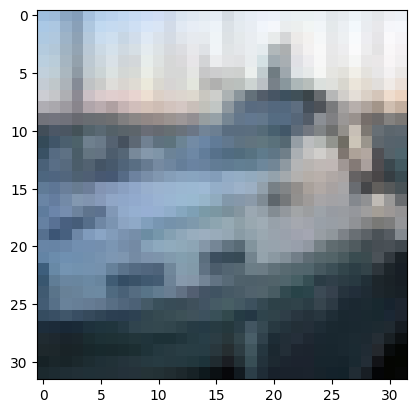

In [ ]:
plt.imshow(pil_img.squeeze().permute(1, 2, 0))
print('Label:', classes[label])

In [ ]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
targets = [ClassifierOutputTarget(label)]

In [ ]:
# The target for the CAM is the Frog category.
# As usual for classication, the target is the logit output
# before softmax, for that category.
target_layers = [model.network[12]]

In [ ]:
img_float = np.float32(pil_img.squeeze().permute(1, 2, 0)) / 255

In [ ]:
input_tensor = preprocess_image(img_float, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [ ]:
# The target for the CAM is the Frog category.
# As usual for classication, the target is the logit output
# before softmax, for that category.
with GradCAM(model=model, target_layers=target_layers) as cam:
  # Construct the CAM object once, and then re-use it on many images:
  # You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
  grayscale_cams = cam(input_tensor=input_tensor, targets=targets)
  # grayscale_cams = cam(input_tensor=input_tensor)
  cam_image = show_cam_on_image(img_float, grayscale_cams[0, :], use_rgb=True)

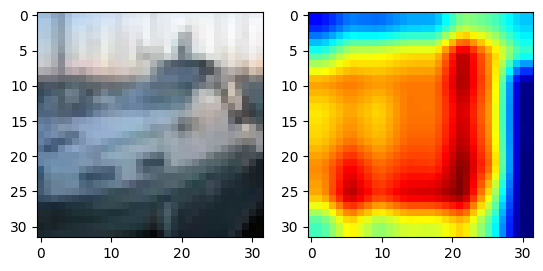

In [ ]:
# plot a sample image and its corresponding upsampled gradcam
# gradcam is upsample to (32, 32) only for visualization purposes
plt.subplot(1, 2, 1)
plt.imshow(pil_img.squeeze().permute(1, 2, 0), cmap='viridis')

plt.subplot(1, 2, 2)
plt.imshow(cam_image, cmap='viridis')